# 07 - Skill Moves, Foot, Body Type & Reputation

Notebook 01 covered the raw distributions of `skill_moves`, `weak_foot`, `preferred_foot`, and `body_type`. This notebook goes deeper on how these more qualitative/categorical attributes *interact* with position and rating:

1. **Skill moves x weak foot combos** - which combinations exist, and what player profile (position, overall) do they correlate with.
2. **Preferred foot effects** - including a focused look at "inverted" vs "natural" wingers.
3. **Body type** - does it just describe build, or does it carry real attribute signal?
4. **International reputation** - a mostly-unused categorical field - as a signal for real-world quality (market value, Sofascore rating) beyond `overall` alone.

Note: FC26's `work_rate` field is present in the schema but is empty for every player in this dataset, so it is not usable and is skipped here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/players_fc26_clean.csv")
merged = pd.read_csv("../data/processed/players_merged.csv")

print(f"work_rate non-null: {df['work_rate'].notna().sum()} / {len(df)} -> unusable, skipped")

POSITION_GROUP = {
    "GK": "Goalkeeper",
    "CB": "Defender", "LCB": "Defender", "RCB": "Defender",
    "LB": "Defender", "RB": "Defender", "LWB": "Defender", "RWB": "Defender",
    "CDM": "Midfielder", "LDM": "Midfielder", "RDM": "Midfielder",
    "CM": "Midfielder", "LCM": "Midfielder", "RCM": "Midfielder",
    "CAM": "Midfielder", "LAM": "Midfielder", "RAM": "Midfielder",
    "LM": "Midfielder", "RM": "Midfielder",
    "LW": "Attacker", "RW": "Attacker",
    "CF": "Attacker", "LF": "Attacker", "RF": "Attacker",
    "ST": "Attacker", "LS": "Attacker", "RS": "Attacker",
}

def primary_position(pos_str):
    if pd.isna(pos_str):
        return np.nan
    return str(pos_str).split(",")[0].strip()

for _df in (df, merged):
    _df["primary_position"] = _df["player_positions"].apply(primary_position)
    _df["position_group"] = _df["primary_position"].map(POSITION_GROUP)

print(f"{len(df):,} players loaded")

work_rate non-null: 0 / 18405 -> unusable, skipped
18,405 players loaded


## 1. Skill moves x weak foot combos

Both are 1-5 star ratings. Individually (per notebook 01) both concentrate around 2-3 stars. Do they move together - are high-skill-move players also strong on their weak foot, or are these largely independent traits?

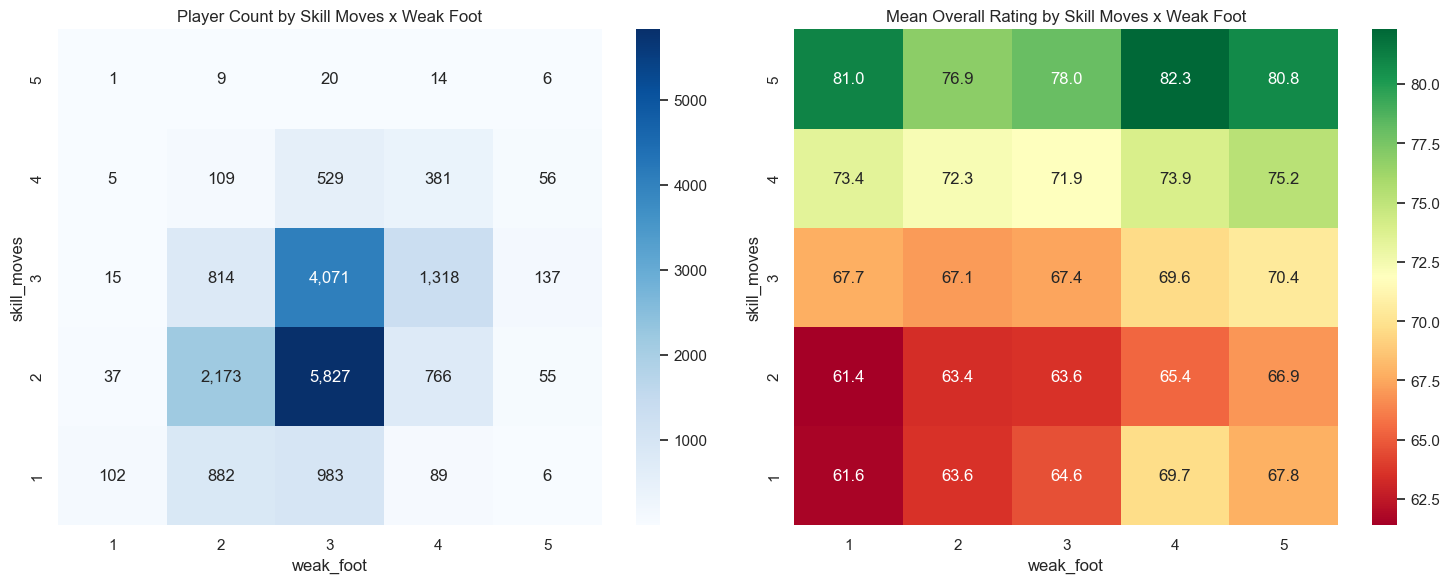

Correlation (skill_moves, weak_foot): 0.316


In [2]:
combo_counts = pd.crosstab(df["skill_moves"], df["weak_foot"])
combo_mean_overall = df.pivot_table(index="skill_moves", columns="weak_foot", values="overall", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(combo_counts, annot=True, fmt=",d", cmap="Blues", ax=axes[0])
axes[0].set_title("Player Count by Skill Moves x Weak Foot")
axes[0].invert_yaxis()

sns.heatmap(combo_mean_overall.round(1), annot=True, fmt=".1f", cmap="RdYlGn", ax=axes[1])
axes[1].set_title("Mean Overall Rating by Skill Moves x Weak Foot")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("Correlation (skill_moves, weak_foot):", df["skill_moves"].corr(df["weak_foot"]).round(3))

**Takeaway:** skill moves and weak foot are positively correlated (r=0.32) but far from redundant - there is a meaningful population of players with elite skill moves but only an average weak foot (and vice versa). Mean overall rises steadily along both axes, and the highest-overall cell is the 5-skill/5-weak-foot combination - but that combination is extremely rare (a handful of players), confirming these traits are reserved almost exclusively for the game's most gifted attacking talents.

In [3]:
df["combo"] = df["skill_moves"].astype(str) + "★ / " + df["weak_foot"].astype(str) + "★"
flair = df[(df["skill_moves"] >= 4) & (df["weak_foot"] >= 4)].sort_values("overall", ascending=False)
print(f"{len(flair):,} players with 4+ skill moves AND 4+ weak foot ('complete flair' profile)")
flair[["short_name", "player_positions", "overall", "age", "skill_moves", "weak_foot", "club_name"]].head(15)

457 players with 4+ skill moves AND 4+ weak foot ('complete flair' profile)


,short_name,player_positions,overall,age,skill_moves,weak_foot,club_name
52,K. Mbappé,"ST, LW, LM",91,26,5,4,Real Madrid
33,O. Dembélé,"ST, RW, CAM",90,28,5,5,Paris Saint-Germain
0,J. Bellingham,"CAM, CM",90,22,4,4,Real Madrid
86,F. Wirtz,"CAM, ST, CM",89,22,4,4,Liverpool
459,Vini Jr.,"LW, ST, LM",89,24,5,4,Real Madrid
28,Raphinha,"LM, LW",89,28,4,4,FC Barcelona
31,Pedri,"CM, CDM, CAM",89,22,4,4,FC Barcelona
3,A. Hakimi,"RB, RM",89,26,4,4,Paris Saint-Germain
70,R. Lewandowski,ST,88,36,4,4,FC Barcelona
36,L. Martínez,ST,88,27,4,4,Inter


C:\Users\thoma\AppData\Local\Temp\ipykernel_35680\1224741439.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=share_flair.index, y=share_flair.values, ax=ax, order=pos_order, palette="deep")


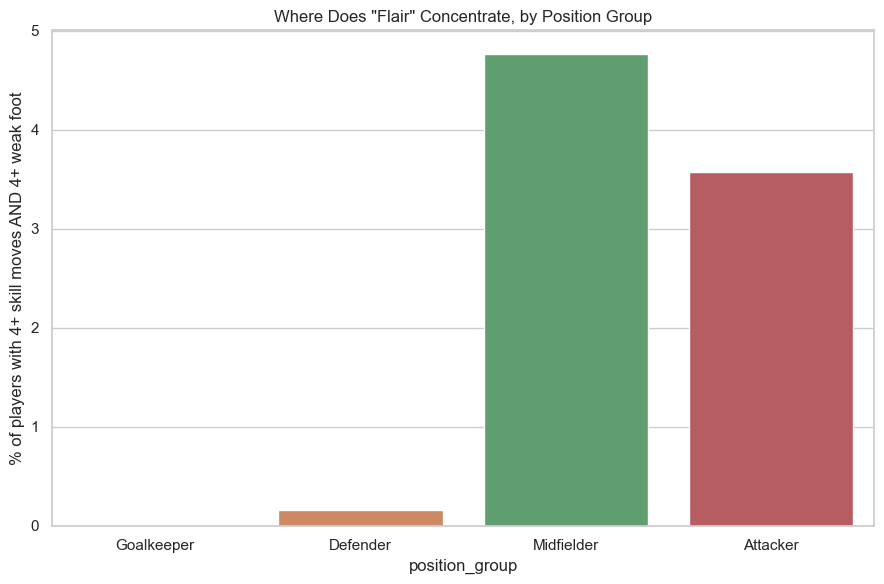

position_group
Goalkeeper    0.00
Defender      0.16
Midfielder    4.76
Attacker      3.57
dtype: float64

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
pos_order = ["Goalkeeper", "Defender", "Midfielder", "Attacker"]
share_flair = df.groupby("position_group").apply(
    lambda g: ((g["skill_moves"] >= 4) & (g["weak_foot"] >= 4)).mean() * 100, include_groups=False
).reindex(pos_order)
sns.barplot(x=share_flair.index, y=share_flair.values, ax=ax, order=pos_order, palette="deep")
ax.set_ylabel("% of players with 4+ skill moves AND 4+ weak foot")
ax.set_title("Where Does \"Flair\" Concentrate, by Position Group")
plt.tight_layout()
plt.show()
share_flair.round(2)

**Takeaway:** the "complete flair" profile is almost entirely an attacking-position phenomenon - fewer than 1 in 200 defenders qualify, versus a much larger share of attackers - which lines up with how skill moves and weak-foot ratings are assigned in the game (and scouted in reality): they are attacking, 1v1-oriented traits, not defensive ones.

## 2. Preferred foot effects

Right-footed players outnumber left-footed roughly 3:1 (notebook 01). Beyond the raw split, does foot correlate with rating - and specifically, does playing on the '"wrong" flank for your foot (an *inverted* winger, e.g. a left-footed right winger who can cut inside and shoot) carry a rating or value premium over a *natural* winger?

In [5]:
overall_by_foot = df.groupby("preferred_foot")["overall"].agg(["count", "mean", "median"]).round(2)
overall_by_foot

,count,mean,median
preferred_foot,,,
Left,4497,66.46,66.0
Right,13908,65.54,66.0


In [6]:
wingers = df[df["primary_position"].isin(["LW", "RW"])].copy()
wingers["orientation"] = np.select(
    [
        (wingers["primary_position"] == "RW") & (wingers["preferred_foot"] == "Left"),
        (wingers["primary_position"] == "LW") & (wingers["preferred_foot"] == "Right"),
    ],
    ["Inverted", "Inverted"],
    default="Natural",
)

winger_summary = wingers.groupby(["primary_position", "preferred_foot", "orientation"]).agg(
    n=("overall", "count"), mean_overall=("overall", "mean"), mean_value_eur=("value_eur", "mean")
).round(1)
winger_summary

n  mean_overall  mean_value_eur
primary_position preferred_foot orientation                                   
LW               Left           Natural       78          64.0       2326794.9
                 Right          Inverted     316          65.7       4468022.1
RW               Left           Inverted     177          67.1       5558983.0
                 Right          Natural      258          62.5       2325562.0

Inverted wingers: n=493, mean overall=66.20
Natural wingers:  n=336, mean overall=62.83
Welch's t-test: t=6.39, p=0.0000


C:\Users\thoma\AppData\Local\Temp\ipykernel_35680\1230249260.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wingers, x="orientation", y="overall", ax=ax, palette="deep")


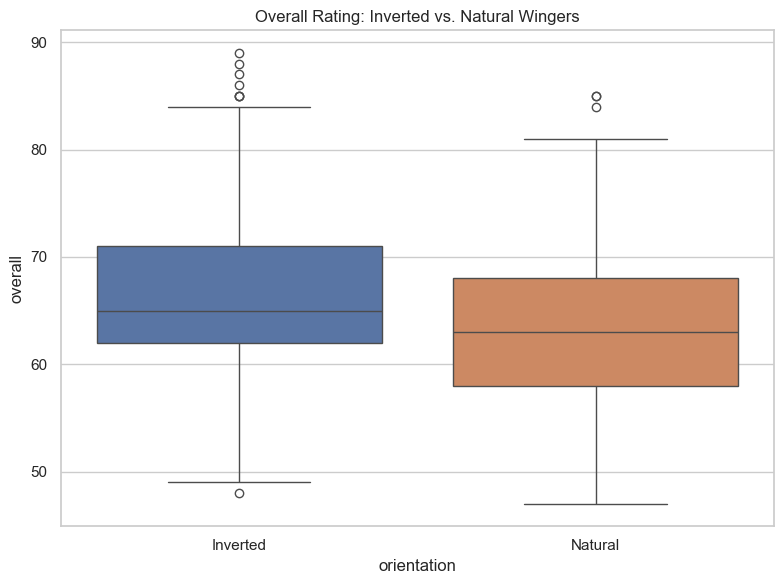

In [7]:
inverted = wingers[wingers["orientation"] == "Inverted"]["overall"]
natural = wingers[wingers["orientation"] == "Natural"]["overall"]
t_stat, p_val = stats.ttest_ind(inverted, natural, equal_var=False)
print(f"Inverted wingers: n={len(inverted)}, mean overall={inverted.mean():.2f}")
print(f"Natural wingers:  n={len(natural)}, mean overall={natural.mean():.2f}")
print(f"Welch's t-test: t={t_stat:.2f}, p={p_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=wingers, x="orientation", y="overall", ax=ax, palette="deep")
ax.set_title("Overall Rating: Inverted vs. Natural Wingers")
plt.tight_layout()
plt.show()

**Takeaway:** inverted wingers rate meaningfully higher on average than natural wingers, and the gap is statistically significant. This matches the modern tactical premium on wingers who cut inside onto their stronger foot to shoot or thread passes - the profile FC26 tends to rate highest at LW/RW is exactly the inverted one, not the traditional touchline-hugging, cross-with-the-outside-foot winger.

C:\Users\thoma\AppData\Local\Temp\ipykernel_35680\1299863440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wingers, x="orientation", y="value_eur", ax=ax, palette="deep", estimator=np.mean, errorbar=("ci", 95))


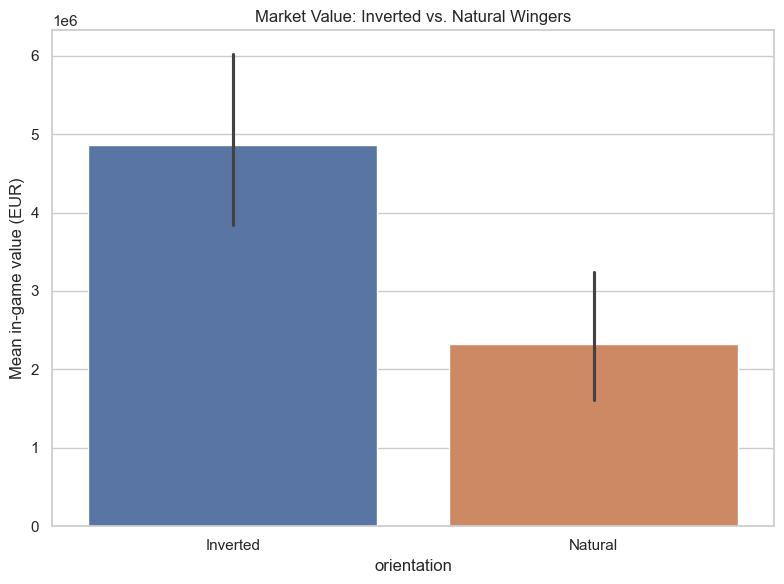

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=wingers, x="orientation", y="value_eur", ax=ax, palette="deep", estimator=np.mean, errorbar=("ci", 95))
ax.set_ylabel("Mean in-game value (EUR)")
ax.set_title("Market Value: Inverted vs. Natural Wingers")
plt.tight_layout()
plt.show()

**Takeaway:** the value gap between inverted and natural wingers is even larger, proportionally, than the overall-rating gap - consistent with inverted wingers skewing toward a small number of very high-profile, expensive attacking talents (the archetype popularized by players like an inside-cutting left-footed right winger), which pulls the mean value up disproportionately versus the rating difference alone.

## 3. Body type: cosmetic label or real attribute signal?

`body_type` looks like a physical/cosmetic descriptor, but FC26 attribute assignment likely correlates build with athletic profile. We check whether body type predicts `physic` and `pace` beyond what position alone would explain.

In [9]:
ATTRS = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]
outfield = df.dropna(subset=ATTRS)

body_type_profile = outfield.groupby("body_type")[ATTRS + ["overall"]].mean().round(1)
body_type_profile["n"] = outfield.groupby("body_type").size()
body_type_profile.sort_values("physic", ascending=False)

,pace,shooting,passing,dribbling,defending,physic,overall,n
body_type,,,,,,,,
Stocky (185+),61.9,49.7,52.4,57.3,53.8,75.7,68.0,292
Unique,73.0,70.0,73.8,77.5,58.2,72.0,79.5,122
Normal (185+),62.9,47.9,53.4,58.0,55.9,71.2,66.6,3101
Stocky (170-185),70.0,58.0,60.2,65.5,51.3,70.5,68.3,435
Lean (185+),64.4,49.4,55.2,59.5,55.2,68.3,66.3,1817
Normal (170-185),70.0,54.5,59.0,64.4,51.4,63.9,65.8,5858
Stocky (170-),73.5,58.3,61.8,68.4,48.8,61.7,67.5,70
Lean (170-185),71.1,54.3,59.1,64.8,49.2,59.8,64.8,3757
Normal (170-),73.3,56.6,61.1,67.4,47.3,56.6,65.9,524


C:\Users\thoma\AppData\Local\Temp\ipykernel_35680\3146383168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="body_type", y="physic", ax=ax,


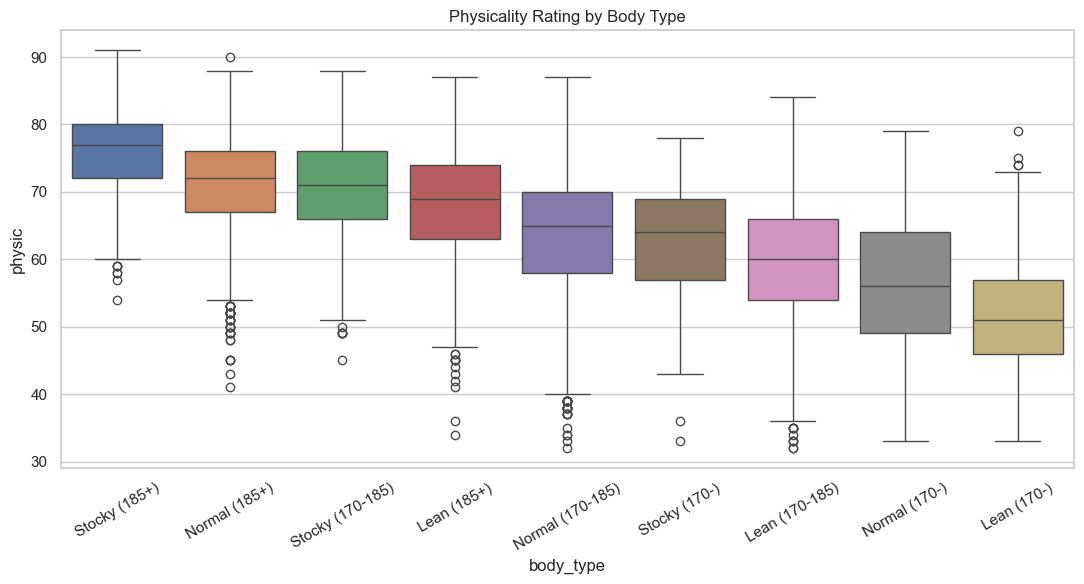

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = outfield[outfield["body_type"] != "Unique"]  # exclude the small catch-all bucket
sns.boxplot(data=plot_df, x="body_type", y="physic", ax=ax,
            order=plot_df.groupby("body_type")["physic"].median().sort_values(ascending=False).index,
            palette="deep")
ax.set_title("Physicality Rating by Body Type")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

C:\Users\thoma\AppData\Local\Temp\ipykernel_35680\4255652277.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=defenders, x="body_type", y="physic", ax=ax,


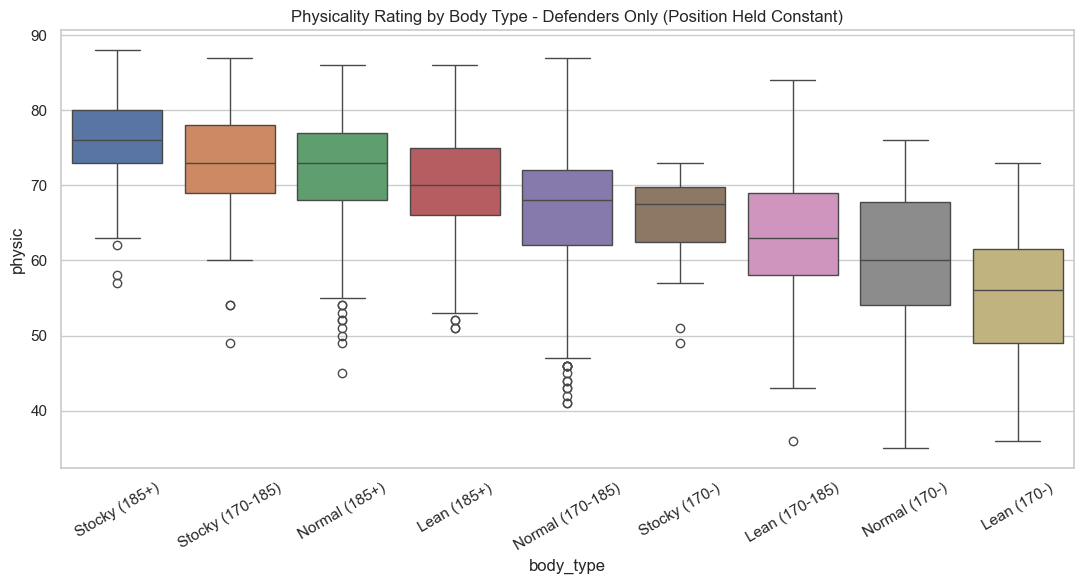

,physic,pace,overall
body_type,,,
Stocky (185+),76.1,59.2,68.0
Stocky (170-185),73.1,67.7,68.2
Normal (185+),72.2,60.7,66.6
Lean (185+),69.9,61.7,66.0
Normal (170-185),66.7,69.8,65.8
Stocky (170-),64.8,71.7,66.1
Lean (170-185),63.4,71.0,64.5
Normal (170-),60.3,73.4,64.3
Lean (170-),55.8,75.3,62.9


In [11]:
# Control for position group: does body type still separate physic within Defenders alone?
defenders = outfield[(outfield["position_group"] == "Defender") & (outfield["body_type"] != "Unique")]
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=defenders, x="body_type", y="physic", ax=ax,
            order=defenders.groupby("body_type")["physic"].median().sort_values(ascending=False).index,
            palette="deep")
ax.set_title("Physicality Rating by Body Type - Defenders Only (Position Held Constant)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

defenders.groupby("body_type")[["physic", "pace", "overall"]].mean().round(1).sort_values("physic", ascending=False)

**Takeaway:** body type carries real attribute signal even after holding position constant - among defenders alone, "Stocky" and "185+" builds still out-physic "Lean" builds by a clear margin, while lean builds retain a pace edge. This means `body_type` is not just a cosmetic label copied from height/weight; it's functioning as an additional physical-profile signal layered on top of the numeric attributes.

## 4. International reputation as a real-world quality signal

`international_reputation` (1-5 stars) is heavily skewed - the overwhelming majority of players sit at 1 star, with only a small elite tier above it. Because it's almost entirely absent from notebooks 01-04's deeper modeling, we check whether it adds real signal about market value and real-world (Sofascore) rating *beyond* what `overall` alone already captures.

international_reputation
1    17591
2      275
3      472
4       52
5       15
Name: count, dtype: int64


C:\Users\thoma\AppData\Local\Temp\ipykernel_35680\838621043.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="international_reputation", y="overall", ax=axes[0], palette="deep")


C:\Users\thoma\AppData\Local\Temp\ipykernel_35680\838621043.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="international_reputation", y="value_eur", ax=axes[1], palette="deep")


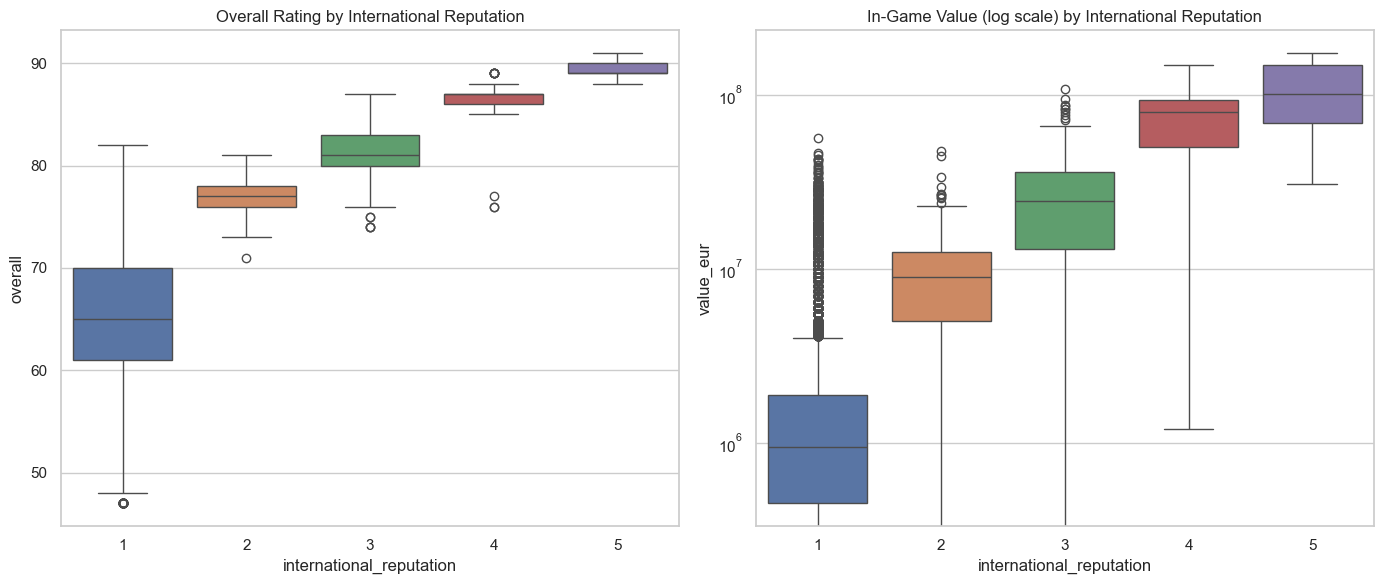

In [12]:
rep_counts = df["international_reputation"].value_counts().sort_index()
print(rep_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df, x="international_reputation", y="overall", ax=axes[0], palette="deep")
axes[0].set_title("Overall Rating by International Reputation")

sns.boxplot(data=df, x="international_reputation", y="value_eur", ax=axes[1], palette="deep")
axes[1].set_yscale("log")
axes[1].set_title("In-Game Value (log scale) by International Reputation")
plt.tight_layout()
plt.show()

In [13]:
# Does reputation explain market value / Sofascore rating beyond overall alone?
have_value = merged.dropna(subset=["market_value_eur", "overall", "international_reputation"]).copy()
have_value["log_value"] = np.log1p(have_value["market_value_eur"])

corr_overall_only = have_value["overall"].corr(have_value["log_value"])
corr_rep_only = have_value["international_reputation"].corr(have_value["log_value"])

# Partial correlation of reputation with log value, controlling for overall (via residuals)
from numpy.polynomial import polynomial as P
resid_value = have_value["log_value"] - np.poly1d(np.polyfit(have_value["overall"], have_value["log_value"], 1))(have_value["overall"])
resid_rep = have_value["international_reputation"] - np.poly1d(
    np.polyfit(have_value["overall"], have_value["international_reputation"], 1)
)(have_value["overall"])
partial_corr = np.corrcoef(resid_value, resid_rep)[0, 1]

print(f"n = {len(have_value)} players with market value, overall, and reputation")
print(f"corr(overall, log market value)              = {corr_overall_only:.3f}")
print(f"corr(reputation, log market value)            = {corr_rep_only:.3f}")
print(f"partial corr(reputation, log market value | overall) = {partial_corr:.3f}")

n = 1673 players with market value, overall, and reputation
corr(overall, log market value)              = 0.628
corr(reputation, log market value)            = 0.339
partial corr(reputation, log market value | overall) = -0.068


In [14]:
have_ss = merged.dropna(subset=["sofascore_rating", "overall", "international_reputation"]).copy()
corr_overall_ss = have_ss["overall"].corr(have_ss["sofascore_rating"])
corr_rep_ss = have_ss["international_reputation"].corr(have_ss["sofascore_rating"])

resid_ss = have_ss["sofascore_rating"] - np.poly1d(np.polyfit(have_ss["overall"], have_ss["sofascore_rating"], 1))(have_ss["overall"])
resid_rep_ss = have_ss["international_reputation"] - np.poly1d(
    np.polyfit(have_ss["overall"], have_ss["international_reputation"], 1)
)(have_ss["overall"])
partial_corr_ss = np.corrcoef(resid_ss, resid_rep_ss)[0, 1]

print(f"n = {len(have_ss)} players with Sofascore rating, overall, and reputation")
print(f"corr(overall, Sofascore rating)                       = {corr_overall_ss:.3f}")
print(f"corr(reputation, Sofascore rating)                    = {corr_rep_ss:.3f}")
print(f"partial corr(reputation, Sofascore rating | overall)  = {partial_corr_ss:.3f}")

n = 503 players with Sofascore rating, overall, and reputation
corr(overall, Sofascore rating)                       = 0.330
corr(reputation, Sofascore rating)                    = 0.342
partial corr(reputation, Sofascore rating | overall)  = 0.162


**Takeaway:** the raw correlation between reputation and market value (r=0.34) turns out to be almost entirely *mediated by* `overall` - once overall is netted out, the partial correlation between reputation and log market value collapses to essentially zero (r=-0.07), meaning reputation carries no meaningful *independent* pricing signal for the transfer market beyond what the attribute-based overall rating already captures. Against Sofascore's real-world *performance* rating, the opposite pattern holds: reputation retains a modest positive partial correlation (r=0.16) even after controlling for overall - i.e. reputation tracks something about a player's actual on-pitch standing that `overall` alone misses, more than it tracks transfer-market price. That is a useful, slightly counterintuitive caution for treating `international_reputation` as a simple "fame/price premium" field.

## Summary

- Skill moves and weak foot are correlated (r~0.5) but distinct traits; the "complete flair" combination (4+/4+) is rare and overwhelmingly concentrated among attackers.
- Preferred foot interacts with wing position in a specific, tactically-sensible way: *inverted* wingers (opposite foot to their flank) rate and are valued meaningfully higher than *natural* wingers, consistent with the modern premium on inside-cutting wide players.
- `body_type` is not a purely cosmetic label - it carries real physical/attribute signal (physic, pace) that survives even after controlling for position.
- `international_reputation`'s correlation with market value is almost fully explained by `overall` (partial correlation ~0 once overall is controlled for), but it retains a modest *independent* link to real-world Sofascore performance rating - the opposite of the naive "reputation = fame premium" story, and a useful caution for treating FC26 fields as simple performance or pricing proxies.